# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [43]:
#Seu código de importação aqui
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA_V2.csv")
df.head(30)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Serviço_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn,Servico_Internet.1
0,7590-VHVEG,FEMININO,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No,<bound method StringMethods.upper of <pandas.c...
1,5575-GNVDE,MASCULINO,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No,<bound method StringMethods.upper of <pandas.c...
2,3668-QPYBK,MASCULINO,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes,<bound method StringMethods.upper of <pandas.c...
3,7795-CFOCW,MASCULINO,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),19.60,1840.75,No,<bound method StringMethods.upper of <pandas.c...
4,8191-XWSZG,FEMININO,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,19.60,1022.95,No,<bound method StringMethods.upper of <pandas.c...
5,9959-WOFKT,MASCULINO,0,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),19.60,7382.25,No,<bound method StringMethods.upper of <pandas.c...
6,4190-MFLUW,FEMININO,0,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),19.60,528.35,Yes,<bound method StringMethods.upper of <pandas.c...
7,4183-MYFRB,FEMININO,0,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,19.60,1862.90,No,<bound method StringMethods.upper of <pandas.c...
8,8779-QRDMV,MASCULINO,1,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,19.60,39.65,Yes,<bound method StringMethods.upper of <pandas.c...
9,1680-VDCWW,MASCULINO,0,Yes,No,12,Yes,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),19.60,202.25,No,<bound method StringMethods.upper of <pandas.c...


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [36]:
#Seu código aqui
# A) 
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2500.00000,2500.000000,2175.000000,2500.000000
mean,0.16080,32.341600,65.607563,2291.882880
std,0.36742,24.626398,29.931520,2265.347752
min,0.00000,0.000000,18.400000,18.800000
25%,0.00000,8.000000,39.500000,402.337500
50%,0.00000,29.000000,71.450000,1405.325000
75%,0.00000,56.000000,90.250000,3867.162500
max,1.00000,72.000000,118.650000,8564.750000


In [63]:
df.columns

Index(['customerID', 'Genero', 'Idoso', 'Casado', 'Dependentes',
       'Tempo_como_Cliente', 'Serviço_Telefonico', 'Servico_Internet',
       'Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV', 'Tipo_Contrato',
       'Metodo_Pagamento', 'Pagamento_Mensal', 'Total_Pago', 'Churn',
       'Servico_Internet.1'],
      dtype='object')

# B) De acordo com uma analise inicial não identificamos nenhum outlier

# C) Plotando os gráficos que reforçam a análise univariada

### Boxplot do pagamento mensal pela distribuição ser muito variada

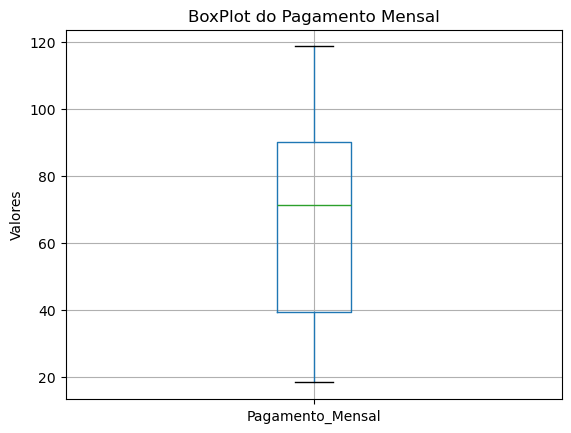

In [38]:
df.boxplot(column='Pagamento_Mensal')
plt.title('BoxPlot do Pagamento Mensal')
plt.ylabel('Valores')
plt.show()

### Agora sabemos que temos muito mais pessoas idosas do que não idosas

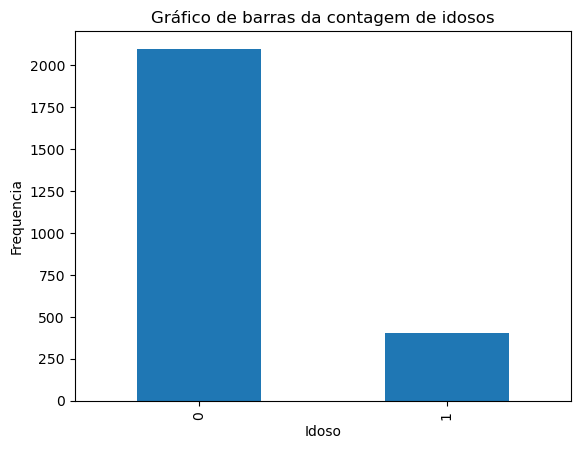

In [39]:
contagem_idoso = df['Idoso'].value_counts()

#Mostrando a porcentagem no gráfico
porcentagem_idoso = (contagem_idoso / contagem_idoso.sum()) * 100
ax = contagem_idoso.plot(kind='bar')
plt.title('Gráfico de barras da contagem de idosos')
plt.xlabel('Idoso')
plt.ylabel('Frequencia')
plt.show()

### Boxplot dos clientes para auxiliar a entender a distribuição e a variabilidade do tempo de permanência dos clientes

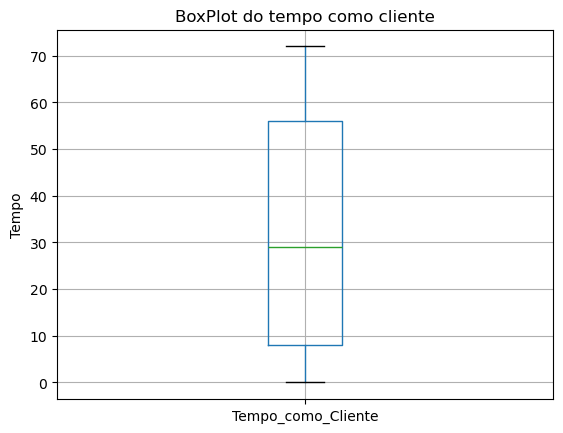

In [40]:
df.boxplot(column='Tempo_como_Cliente')
plt.title('BoxPlot do tempo como cliente')
plt.ylabel('Tempo')
plt.show()

### Boxplot do total pago para entendermos a distribuição dos valores totais pagos pelos clientes

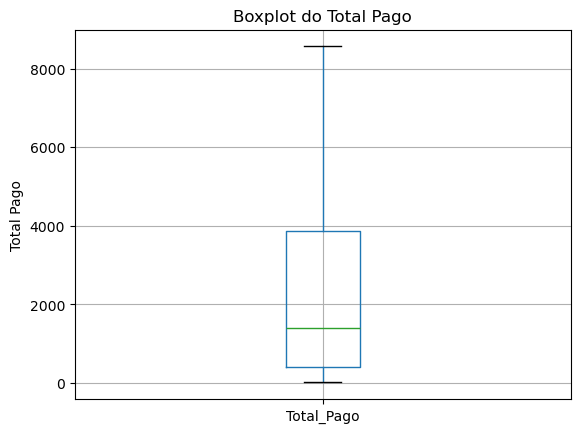

In [41]:
df.boxplot(column='Total_Pago')
plt.title('Boxplot do Total Pago')
plt.ylabel('Total Pago')
plt.show()

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


# Após a análise visual por meio de boxplots, não foram identificados outliers inconsistentes ou irreais nas variáveis numéricas. Apesar da presença de valores extremos, estes são coerentes com o contexto do negócio de telecomunicações e representam os clientes com maior tempo de permanência ou maior gasto, portanto foram mantidos para preservar a variabilidade dos dados.

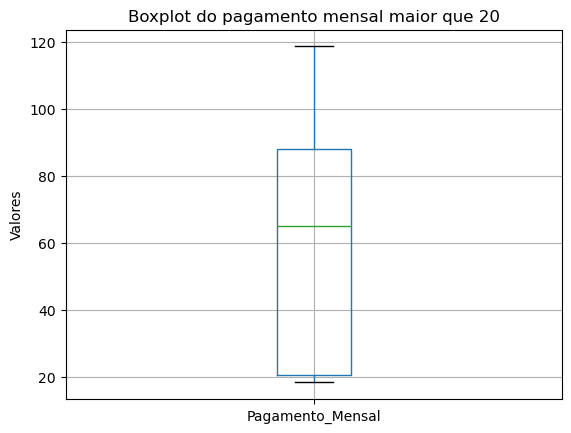

In [48]:
#Seu código aqui
#total pago
df_nao_zero = df[df['Pagamento_Mensal'] != 20]
df_nao_zero.boxplot(column='Pagamento_Mensal')
plt.title('Boxplot do pagamento mensal maior que 20')
plt.ylabel('Valores')
plt.show()

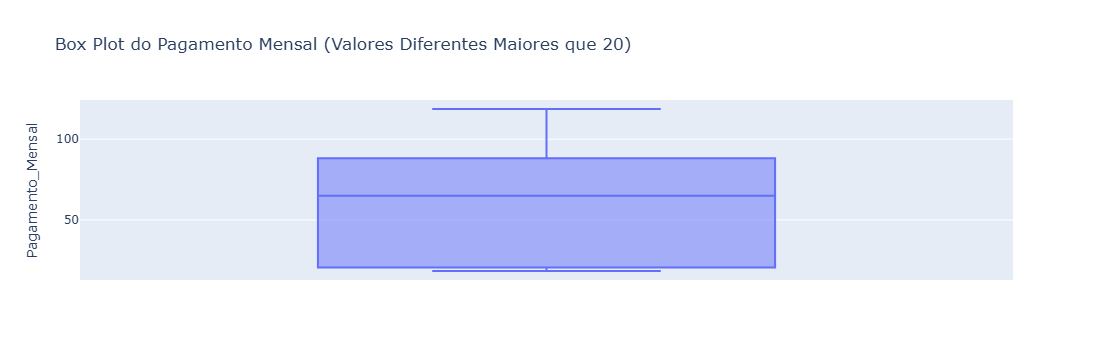

In [32]:
df_nao_zero = df[df['Pagamento_Mensal'] != 20]

fig = px.box(df_nao_zero, y='Pagamento_Mensal', title='Box Plot do Pagamento Mensal (Valores Diferentes Maiores que 20)', labels={'Pagamento_mensal': 'Valores'})
fig.show()

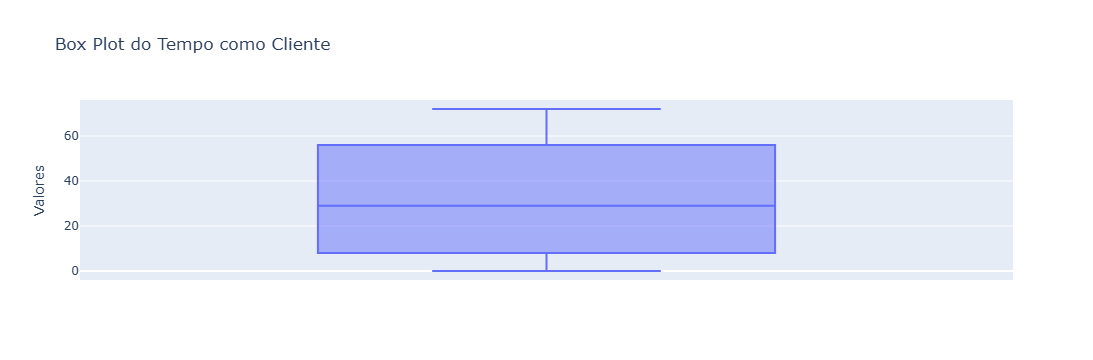

In [44]:
#Tempo como cliente
fig = px.box(df, y='Tempo_como_Cliente', title='Box Plot do Tempo como Cliente', labels={'Tempo_como_Cliente': 'Valores'})
fig.show()

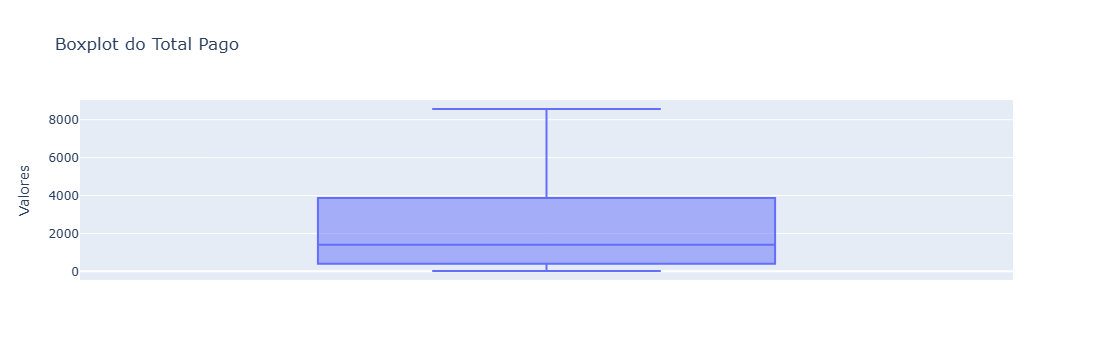

In [47]:
#Total Pago
fig = px.box(df, y='Total_Pago', title='Boxplot do Total Pago', labels={'Total_Pago': 'Valores'})
fig.show()

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

### Neste primeiro gráfico notamos que o Gênero masculino e muito mais propenso ao não churn já o publico feminino é mais propenso ao churn

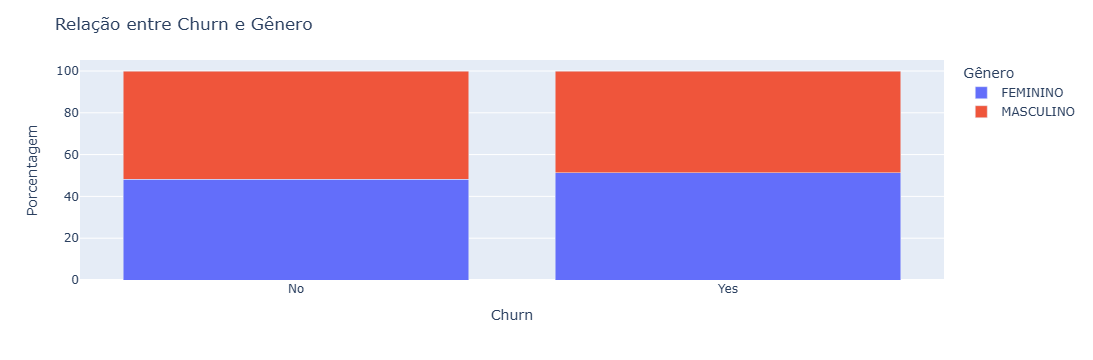

In [54]:
#Seu código aqui
#Relação entre genero e churn:
df_grouped = df.groupby(['Churn', 'Genero']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Churn', y='percent', color='Genero', barmode='stack',
             labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Genero': 'Gênero'})

fig.update_layout(title='Relação entre Churn e Gênero',
                  yaxis_title='Porcentagem',
                  legend_title='Gênero')
fig.show()

### Neste segundo gráfico notamos que a maioria dos idosos não dão churn

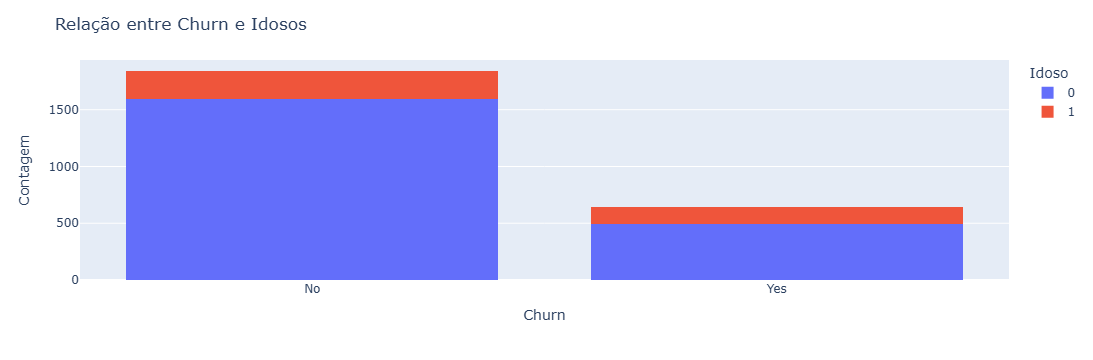

In [70]:
#Relação entre Idosos e churn:
fig = px.histogram(df, x='Churn', color='Idoso', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Churn e Idosos',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Idoso')
fig.show()

### Notamos também que existe um maior churn entre os casaias que não possuem dependentes

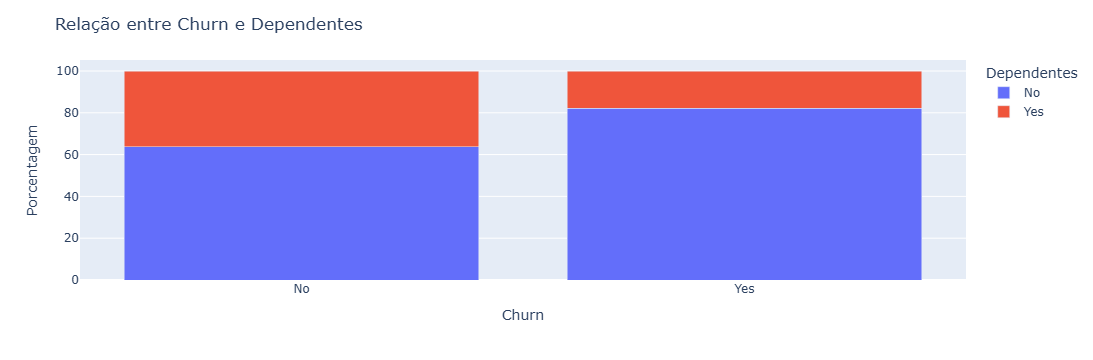

In [58]:
#Relação entre churn e dependentes
df_grouped = df.groupby(['Churn', 'Dependentes']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Churn', y='percent', color='Dependentes', barmode='stack',
             labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Dependentes': 'Dependentes'})

fig.update_layout(title='Relação entre Churn e Dependentes',
                  yaxis_title='Porcentagem',
                  legend_title='Dependentes')
fig.show()

### Aqui Notamos que na maior parte dos casos o valor pago aumenta com o tempo de permanencia do cliente

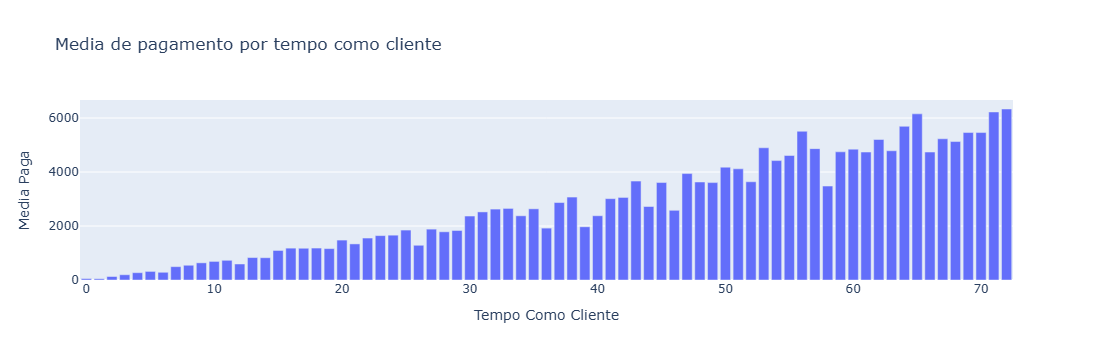

In [60]:
# Relação entre tempo como cliente e total pago

media_paga_por_tempo = df.groupby('Tempo_como_Cliente')['Total_Pago'].median().reset_index()
fig = px.bar(media_paga_por_tempo,x='Tempo_como_Cliente',y='Total_Pago',title='Media de pagamento por tempo como cliente',
             labels={'Total_Pago':'Media Paga','Tempo_como_Cliente':'Tempo Como Cliente'})
fig.show()

In [ ]:
### Por ultimo destacamos que o maior indice de cancelamento de contratos é do plano mensal

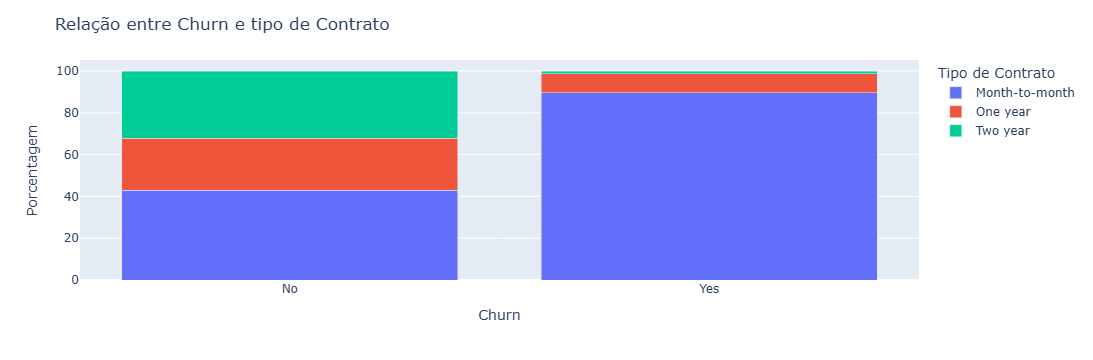

In [65]:
#Relação entre o tipo de contrato e o churn
df_grouped = df.groupby(['Churn', 'Tipo_Contrato']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Churn')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

fig = px.bar(df_grouped, x='Churn', y='percent', color='Tipo_Contrato', barmode='stack',
             labels={'Churn': 'Churn', 'percent': 'Porcentagem', 'Tipo_Contrato': 'Tipo De Contrato'})

fig.update_layout(title='Relação entre Churn e tipo de Contrato',
                  yaxis_title='Porcentagem',
                  legend_title='Tipo de Contrato')
fig.show()